# Classifier Pretrain Comparison

> Note: This notebook uses **ensemble-then-bootstrap** with **real test predictions** from checkpoints: it first aggregates multi-seed probabilities (mean/median), then runs paired bootstrap on aggregated probabilities.


## 1) Setup


In [37]:
import csv
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import torch

from src.utils.runtime_utils import resolve_project_root
from src.utils.bootstrap_ci import (
    aggregate_seed_predictions,
    bootstrap_multi_model_metric_ci,
)
from src.utils.bootstrap_presets import PairedBootstrapPreset
from src.utils.metrics import classification_metrics

from src.data.preparation import prepare_data
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
import src.utils.viz_analysis as analysis

PROJECT_ROOT = resolve_project_root()
print(f'PROJECT_ROOT: {PROJECT_ROOT}')


PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Config

In [38]:
# Multi-seed settings
SEEDS = [0, 1, 2]
SEED_AGG_METHOD = 'mean'  # 'mean' or 'median'
CKPT_FILE_NAME = 'best_model_1.pth'
CLF_BATCH_SIZE = 64
CLF_DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DISK_CACHE_ENABLED = True
DISK_CACHE_DIR = PROJECT_ROOT / 'tmp' / 'notebook_pred_cache' / 'classifier_pretrain_comparison'

# Label used in exported filenames
EXPORT_LABEL = 'pretrain_vs_scratch_multiseed_mean'

# Windows to compare
WINDOWS = [
    (4.0, 10),
    (4.5, 20),
    (4.5, 30),
    (5.0, 60),
    (5.5, 90),
]

# Model display name -> experiment directory
EXPERIMENTS = {
    'AZDX': 'experiments/clf_grid_r_2',
    'AZDX_minus_b': 'experiments/clf_grid_r_2_AZDX_minus_b',
    'SCEDC': 'experiments/clf_grid_r_2_SCEDC',
    'SCEDC_minus_b': 'experiments/clf_grid_r_2_SCEDC_minus_b',
    'Scratch': 'experiments/clf_grid_r_2_scratch',
}

# Which model is used as baseline in pairwise deltas: baseline_minus_other
BASELINE_MODEL = 'Scratch'

EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / 'classifier_pretrain_comparison'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_STEM = 'clf_ci'
ROUND_DECIMALS = 4
THRESHOLD_OPTIMIZE_METRIC = 'f1'
SORT_EXPORT_BY = ('Mf', 'Tfore', 'model')
SORT_DELTA_BY = ('Mf', 'Tfore', 'comparison')

BOOTSTRAP_PRESET = PairedBootstrapPreset(
    sampling='block',
    ci=(2.5, 97.5),
    n_resamples_curve=400,
    n_resamples_metric=800,
    block_size=8,
    circular_block=True,
)

if BASELINE_MODEL not in EXPERIMENTS:
    raise ValueError(f'BASELINE_MODEL not found in EXPERIMENTS: {BASELINE_MODEL}')

if not SEEDS:
    raise ValueError('SEEDS must be non-empty.')

print('Configured models:', list(EXPERIMENTS.keys()))
print('Baseline model:', BASELINE_MODEL)
print('Seeds:', SEEDS)
print('Seed aggregation method:', SEED_AGG_METHOD)
print('Checkpoint file name:', CKPT_FILE_NAME)
print('Inference device:', CLF_DEVICE)
print('Disk cache enabled:', DISK_CACHE_ENABLED)
print('Disk cache dir:', DISK_CACHE_DIR)


Configured models: ['AZDX', 'AZDX_minus_b', 'SCEDC', 'SCEDC_minus_b', 'Scratch']
Baseline model: Scratch
Seeds: [0, 1, 2]
Seed aggregation method: mean
Checkpoint file name: best_model_1.pth
Inference device: cuda:0
Disk cache enabled: True
Disk cache dir: /root/autodl-tmp/em_eqf/tmp/notebook_pred_cache/classifier_pretrain_comparison


## 3) Helpers


In [39]:
def _r4(x):
    if x is None:
        return None
    try:
        return round(float(x), ROUND_DECIMALS)
    except Exception:
        return None


def _mf_token(mf: float) -> str:
    return str(mf).replace('.', 'p')


def _run_name(mf: float, tfore: int, seed: int) -> str:
    return f'tf_{int(tfore)}_mf_{_mf_token(float(mf))}_seed_{int(seed)}'


def _resolve_ckpt_path(exp_dir: str, mf: float, tfore: int, seed: int) -> Path:
    run_name = _run_name(mf, tfore, seed)
    ckpt_path = PROJECT_ROOT / exp_dir / 'runs' / run_name / CKPT_FILE_NAME
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
    return ckpt_path


def _cache_file_for_checkpoint(checkpoint_path: Path) -> Path:
    rel = checkpoint_path.resolve().relative_to(PROJECT_ROOT)
    # keep structure under cache dir and append suffix
    return DISK_CACHE_DIR / rel.with_suffix('.pred_cache.npz')


PREDICTION_CACHE: dict[str, tuple[np.ndarray, np.ndarray]] = {}


def _load_test_scores_from_checkpoint(checkpoint_path: Path):
    ckpt_key = str(checkpoint_path.resolve())

    # 1) in-memory cache
    if ckpt_key in PREDICTION_CACHE:
        y_true_cached, y_prob_cached = PREDICTION_CACHE[ckpt_key]
        return y_true_cached.copy(), y_prob_cached.copy(), None, 'memory'

    # 2) disk cache
    cache_path = _cache_file_for_checkpoint(checkpoint_path)
    if DISK_CACHE_ENABLED and cache_path.exists():
        payload = np.load(cache_path)
        y_true_disk = np.asarray(payload['y_true']).astype(int).reshape(-1)
        y_prob_disk = np.asarray(payload['y_prob'], dtype=np.float64).reshape(-1)
        PREDICTION_CACHE[ckpt_key] = (y_true_disk.copy(), y_prob_disk.copy())
        return y_true_disk, y_prob_disk, None, 'disk'

    # 3) real inference
    check_point = torch.load(checkpoint_path, map_location=CLF_DEVICE, weights_only=False)
    clf_args = load_args_from_checkpoint(None, check_point)

    model_builder = ModelBuilder.by_name(clf_args.model.lower())()
    model = model_builder(clf_args, CLF_DEVICE)
    model, _, _ = load_model_from_checkpoint(model, check_point)
    model.eval()

    clf_args.use_sampler = False
    clf_args.batch_size = CLF_BATCH_SIZE

    base_dir = PROJECT_ROOT / 'data' / clf_args.dataset
    _, _, _, test_loader, _ = prepare_data(args=clf_args, base_dir=str(base_dir))

    y_logits, y_true, _ = analysis.predict_all(
        model,
        test_loader,
        CLF_DEVICE,
        return_X=False,
    )

    logits_np = np.asarray(y_logits, dtype=np.float64).reshape(-1)
    y_prob = 1.0 / (1.0 + np.exp(-np.clip(logits_np, -60.0, 60.0)))
    y_true = np.asarray(y_true).astype(int).reshape(-1)

    PREDICTION_CACHE[ckpt_key] = (y_true.copy(), y_prob.copy())
    if DISK_CACHE_ENABLED:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_path, y_true=y_true, y_prob=y_prob)

    return y_true, y_prob, clf_args, 'inference'


## 4) Load real checkpoint predictions and aggregate multi-seed probabilities


In [40]:
# PREDICTION_CACHE.clear()  # uncomment to force re-run without memory cache
multi_results = []
cache_hits_memory = 0
cache_hits_disk = 0
cache_misses = 0
for idx, (mf, tfore) in enumerate(WINDOWS):
    model_entries = {}

    for model_name, exp_dir in EXPERIMENTS.items():
        y_true_ref = None
        y_prob_seeds = []
        ckpt_paths = []

        for seed in SEEDS:
            ckpt_path = _resolve_ckpt_path(exp_dir, mf, tfore, int(seed))
            y_true_seed, y_prob_seed, _, cache_source = _load_test_scores_from_checkpoint(ckpt_path)
            if cache_source == 'memory':
                cache_hits_memory += 1
            elif cache_source == 'disk':
                cache_hits_disk += 1
            else:
                cache_misses += 1

            if y_true_ref is None:
                y_true_ref = y_true_seed
            elif not np.array_equal(y_true_ref, y_true_seed):
                raise ValueError(
                    f'Label mismatch across seeds for model={model_name}, '
                    f'window=(Mf={mf}, Tfore={tfore}), seed={seed}.'
                )

            y_prob_seeds.append(np.asarray(y_prob_seed, dtype=np.float64))
            ckpt_paths.append(str(ckpt_path))

        y_prob_agg = aggregate_seed_predictions(y_prob_seeds, method=SEED_AGG_METHOD)
        metrics_agg = classification_metrics(
            y_true_ref,
            y_prob_agg,
            threshold=None,
            optimize_metric=THRESHOLD_OPTIMIZE_METRIC,
            apply_sigmoid=False,
        )

        model_entries[model_name] = {
            'metrics': metrics_agg,
            'y_true': y_true_ref,
            'y_prob': y_prob_agg,
            'seed_probs': y_prob_seeds,
            'seeds_used': [int(s) for s in SEEDS],
            'ckpt_paths': ckpt_paths,
        }

    # Align all models on baseline labels for paired bootstrap
    baseline_y_true = np.asarray(model_entries[BASELINE_MODEL]['y_true']).astype(int).reshape(-1)
    for model_name in model_entries:
        y_true_model = np.asarray(model_entries[model_name]['y_true']).astype(int).reshape(-1)
        if y_true_model.shape[0] != baseline_y_true.shape[0] or not np.array_equal(y_true_model, baseline_y_true):
            raise ValueError(
                f'Label mismatch across models at window (Mf={mf}, Tfore={tfore}): '
                f'baseline={BASELINE_MODEL}, current={model_name}.'
            )
        model_entries[model_name]['y_true'] = baseline_y_true

    multi_results.append({
        'window_id': idx,
        'Mf': float(mf),
        'Tfore': int(tfore),
        'models': model_entries,
    })

print(f'Prepared windows: {len(multi_results)}')
print('Models per window:', list(multi_results[0]['models'].keys()) if multi_results else [])
if multi_results:
    first_window = multi_results[0]
    print(
        f"First window aggregated with {len(SEEDS)} seeds per model "
        f"(method={SEED_AGG_METHOD}): Mf={first_window['Mf']}, Tfore={first_window['Tfore']}"
    )
print(f'Prediction cache stats: misses={cache_misses}, hits(memory)={cache_hits_memory}, hits(disk)={cache_hits_disk}, memory_size={len(PREDICTION_CACHE)}')


Prepared windows: 5
Models per window: ['AZDX', 'AZDX_minus_b', 'SCEDC', 'SCEDC_minus_b', 'Scratch']
First window aggregated with 3 seeds per model (method=mean): Mf=4.0, Tfore=10
Prediction cache stats: misses=0, hits(memory)=0, hits(disk)=75, memory_size=75


## 5) AUC Visualization (Multi-Window, with Bootstrap CI)


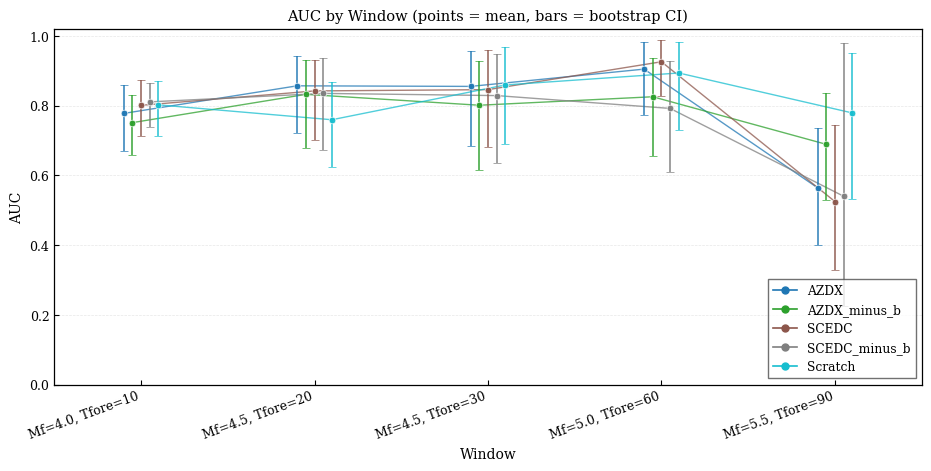

Saved AUC figure (PDF): /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/auc_multi_window_pretrain_vs_scratch_multiseed_mean.pdf
Saved AUC figure (PNG): /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/auc_multi_window_pretrain_vs_scratch_multiseed_mean.png


In [41]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Build AUC summary table from multi_results + bootstrap AUC CI
auc_rows = []
for i, r in enumerate(multi_results):
    y_true_ref = np.asarray(r['models'][BASELINE_MODEL]['y_true']).astype(int).reshape(-1)
    y_prob_by_model = {
        name: np.asarray(r['models'][name]['y_prob'], dtype=np.float64).reshape(-1)
        for name in r['models'].keys()
    }

    auc_result = bootstrap_multi_model_metric_ci(
        y_true=y_true_ref,
        model_predictions=y_prob_by_model,
        metric='auc',
        task='classification',
        config=BOOTSTRAP_PRESET.metric_config(seed=5100 + i),
        baseline_model=BASELINE_MODEL,
    )

    for model_name in r['models'].keys():
        point_auc = float(r['models'][model_name]['metrics']['auc'])
        auc_ci = auc_result.model_results[model_name]
        auc_rows.append(
            {
                'window_id': int(r['window_id']),
                'Mf': float(r['Mf']),
                'Tfore': int(r['Tfore']),
                'model': str(model_name),
                'auc': point_auc,
                'auc_ci_low': float(auc_ci.ci_low),
                'auc_ci_high': float(auc_ci.ci_high),
            }
        )

if not auc_rows:
    raise RuntimeError('No AUC rows available for visualization.')

plot_rc_auc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10.0,
    'axes.labelsize': 10.0,
    'axes.titlesize': 10.5,
    'legend.fontsize': 8.8,
    'xtick.labelsize': 9.0,
    'ytick.labelsize': 9.0,
    'axes.linewidth': 0.9,
}

window_order = [(float(r['Mf']), int(r['Tfore'])) for r in multi_results]
window_labels = [f'Mf={mf:.1f}, Tfore={tf}' for mf, tf in window_order]
window_to_x = {window: idx for idx, window in enumerate(window_order)}

model_names = list(EXPERIMENTS.keys())
colors = plt.cm.tab10(np.linspace(0.0, 1.0, len(model_names)))
model_to_color = {name: colors[i] for i, name in enumerate(model_names)}

# small horizontal offset per model within each window
offset_scale = 0.10
if len(model_names) == 1:
    model_offsets = {model_names[0]: 0.0}
else:
    centered = np.linspace(-1.0, 1.0, len(model_names))
    model_offsets = {name: float(centered[i] * offset_scale) for i, name in enumerate(model_names)}

with plt.rc_context(plot_rc_auc):
    fig, ax = plt.subplots(1, 1, figsize=(9.2, 4.6), constrained_layout=True)

    for row in auc_rows:
        model_name = row['model']
        window_key = (float(row['Mf']), int(row['Tfore']))
        x_base = window_to_x[window_key]
        x = x_base + model_offsets[model_name]

        y = float(row['auc'])
        yerr_low = max(0.0, y - float(row['auc_ci_low']))
        yerr_high = max(0.0, float(row['auc_ci_high']) - y)

        ax.errorbar(
            x,
            y,
            yerr=np.asarray([[yerr_low], [yerr_high]], dtype=np.float64),
            fmt='o',
            markersize=4.8,
            capsize=3.2,
            elinewidth=1.1,
            color=model_to_color[model_name],
            markerfacecolor=model_to_color[model_name],
            markeredgecolor='white',
            markeredgewidth=0.5,
            alpha=0.95,
            zorder=3,
        )

    # connect same-model points across windows for trend readability
    for model_name in model_names:
        rows_m = [r for r in auc_rows if r['model'] == model_name]
        rows_m = sorted(rows_m, key=lambda r: window_to_x[(float(r['Mf']), int(r['Tfore']))])
        xs = [window_to_x[(float(r['Mf']), int(r['Tfore']))] + model_offsets[model_name] for r in rows_m]
        ys = [float(r['auc']) for r in rows_m]
        ax.plot(xs, ys, color=model_to_color[model_name], linewidth=1.0, alpha=0.75, zorder=2)

    ax.set_xticks(np.arange(len(window_order), dtype=np.int64))
    ax.set_xticklabels(window_labels, rotation=20, ha='right')
    ax.set_xlim(-0.5, len(window_order) - 0.5)
    ax.set_ylim(0.0, 1.02)
    ax.set_ylabel('AUC')
    ax.set_xlabel('Window')
    ax.set_title('AUC by Window (points = mean, bars = bootstrap CI)')
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.30)
    ax.tick_params(direction='in', length=3.5, width=0.8)

    legend_handles = [
        Line2D([0], [0], color=model_to_color[name], marker='o', linestyle='-', lw=1.2, markersize=5, label=name)
        for name in model_names
    ]
    ax.legend(handles=legend_handles, loc='lower right', frameon=True, fancybox=False, edgecolor='0.3')

    auc_fig_pdf_path = EXPORT_DIR / f'auc_multi_window_{EXPORT_LABEL}.pdf'
    auc_fig_png_path = EXPORT_DIR / f'auc_multi_window_{EXPORT_LABEL}.png'
    fig.savefig(auc_fig_pdf_path, dpi=300)
    fig.savefig(auc_fig_png_path, dpi=300)
    plt.show()

print(f'Saved AUC figure (PDF): {auc_fig_pdf_path}')
print(f'Saved AUC figure (PNG): {auc_fig_png_path}')


## 5.1) AUC Faceted Plot (2 x 3)


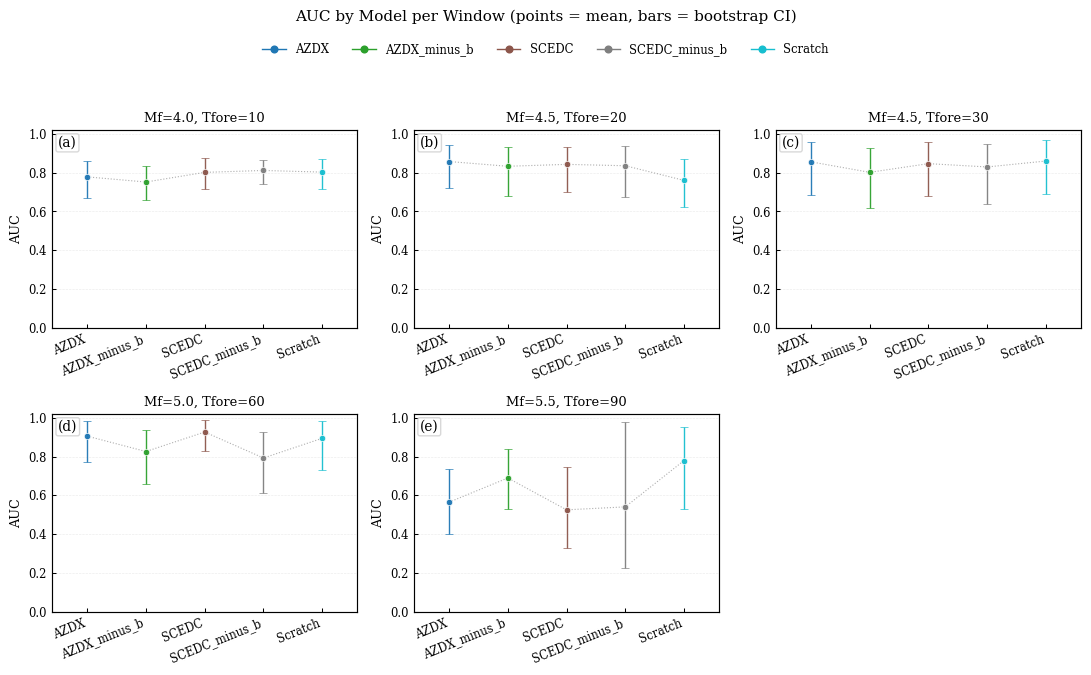

Saved AUC faceted figure (PDF): /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/auc_facet_windows_pretrain_vs_scratch_multiseed_mean_2x3.pdf
Saved AUC faceted figure (PNG): /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/auc_facet_windows_pretrain_vs_scratch_multiseed_mean_2x3.png


In [42]:
# Reuse auc_rows/model_names/model_to_color/window_order from Section 5.
# If Section 5 was not run, rebuild the needed AUC rows first.
if 'auc_rows' not in globals() or len(auc_rows) == 0:
    auc_rows = []
    for i, r in enumerate(multi_results):
        y_true_ref = np.asarray(r['models'][BASELINE_MODEL]['y_true']).astype(int).reshape(-1)
        y_prob_by_model = {
            name: np.asarray(r['models'][name]['y_prob'], dtype=np.float64).reshape(-1)
            for name in r['models'].keys()
        }
        auc_result = bootstrap_multi_model_metric_ci(
            y_true=y_true_ref,
            model_predictions=y_prob_by_model,
            metric='auc',
            task='classification',
            config=BOOTSTRAP_PRESET.metric_config(seed=5100 + i),
            baseline_model=BASELINE_MODEL,
        )
        for model_name in r['models'].keys():
            point_auc = float(r['models'][model_name]['metrics']['auc'])
            auc_ci = auc_result.model_results[model_name]
            auc_rows.append(
                {
                    'window_id': int(r['window_id']),
                    'Mf': float(r['Mf']),
                    'Tfore': int(r['Tfore']),
                    'model': str(model_name),
                    'auc': point_auc,
                    'auc_ci_low': float(auc_ci.ci_low),
                    'auc_ci_high': float(auc_ci.ci_high),
                }
            )

if 'model_names' not in globals():
    model_names = list(EXPERIMENTS.keys())
if 'colors' not in globals():
    colors = plt.cm.tab10(np.linspace(0.0, 1.0, len(model_names)))
if 'model_to_color' not in globals():
    model_to_color = {name: colors[i] for i, name in enumerate(model_names)}

window_order = [(float(r['Mf']), int(r['Tfore'])) for r in multi_results]
window_labels = [f'Mf={mf:.1f}, Tfore={tf}' for mf, tf in window_order]
window_to_rows = {}
for wf in window_order:
    window_to_rows[wf] = [
        row for row in auc_rows
        if float(row['Mf']) == float(wf[0]) and int(row['Tfore']) == int(wf[1])
    ]

facet_rc_auc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9.6,
    'axes.labelsize': 9.2,
    'axes.titlesize': 9.4,
    'legend.fontsize': 8.4,
    'xtick.labelsize': 8.3,
    'ytick.labelsize': 8.3,
    'axes.linewidth': 0.85,
}

n_rows, n_cols = 2, 3
panel_labels = [f'({chr(ord("a") + i)})' for i in range(n_rows * n_cols)]

# consistent x positions for models in each panel
x_positions = np.arange(len(model_names), dtype=np.float64)

with plt.rc_context(facet_rc_auc):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.0, 6.5), squeeze=False, constrained_layout=False)
    axes_flat = axes.ravel()

    for i, ax in enumerate(axes_flat):
        if i >= len(window_order):
            ax.axis('off')
            continue

        wf = window_order[i]
        rows_w = window_to_rows[wf]
        if not rows_w:
            ax.axis('off')
            continue

        row_by_model = {row['model']: row for row in rows_w}

        for j, model_name in enumerate(model_names):
            if model_name not in row_by_model:
                continue
            row = row_by_model[model_name]
            y = float(row['auc'])
            yerr_low = max(0.0, y - float(row['auc_ci_low']))
            yerr_high = max(0.0, float(row['auc_ci_high']) - y)

            ax.errorbar(
                x_positions[j],
                y,
                yerr=np.asarray([[yerr_low], [yerr_high]], dtype=np.float64),
                fmt='o',
                markersize=4.6,
                capsize=3.0,
                elinewidth=1.0,
                color=model_to_color[model_name],
                markerfacecolor=model_to_color[model_name],
                markeredgecolor='white',
                markeredgewidth=0.5,
                alpha=0.95,
            )

        # connect points inside panel for readability
        ys = [float(row_by_model[m]['auc']) if m in row_by_model else np.nan for m in model_names]
        ax.plot(x_positions, ys, color='0.55', linewidth=0.8, linestyle=':', alpha=0.7)

        ax.set_ylim(0.0, 1.02)
        ax.set_xlim(-0.6, len(model_names) - 0.4)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(model_names, rotation=22, ha='right')
        ax.grid(True, axis='y', linestyle='--', linewidth=0.45, alpha=0.25)
        ax.tick_params(direction='in', length=3.2, width=0.75)
        ax.set_ylabel('AUC')

        ax.text(
            0.02,
            0.97,
            panel_labels[i],
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=9.8,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='0.8', alpha=0.75),
        )
        ax.set_title(window_labels[i], pad=6)

    legend_handles = [
        Line2D([0], [0], color=model_to_color[name], marker='o', linestyle='-', lw=1.0, markersize=4.8, label=name)
        for name in model_names
    ]
    fig.legend(
        handles=legend_handles,
        loc='upper center',
        ncol=min(len(legend_handles), 5),
        frameon=False,
        bbox_to_anchor=(0.5, 0.995),
    )

    fig.suptitle('AUC by Model per Window (points = mean, bars = bootstrap CI)', y=1.03, fontsize=11.0)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.94])

    auc_facet_pdf_path = EXPORT_DIR / f'auc_facet_windows_{EXPORT_LABEL}_2x3.pdf'
    auc_facet_png_path = EXPORT_DIR / f'auc_facet_windows_{EXPORT_LABEL}_2x3.png'
    fig.savefig(auc_facet_pdf_path, dpi=300)
    fig.savefig(auc_facet_png_path, dpi=300)
    plt.show()

print(f'Saved AUC faceted figure (PDF): {auc_facet_pdf_path}')
print(f'Saved AUC faceted figure (PNG): {auc_facet_png_path}')


## 7) Export metrics (long + pairwise delta + json)



In [43]:
ci_low_pct, ci_high_pct = BOOTSTRAP_PRESET.ci

metrics_rows = []
delta_rows = []

for i, r in enumerate(multi_results):
    model_names = list(r['models'].keys())

    y_true_ref = np.asarray(r['models'][BASELINE_MODEL]['y_true']).astype(int).reshape(-1)
    y_prob_by_model = {name: np.asarray(r['models'][name]['y_prob'], dtype=np.float64).reshape(-1) for name in model_names}

    auc_result = bootstrap_multi_model_metric_ci(
        y_true=y_true_ref,
        model_predictions=y_prob_by_model,
        metric='auc',
        task='classification',
        config=BOOTSTRAP_PRESET.metric_config(seed=9100 + i),
        baseline_model=BASELINE_MODEL,
    )

    point_metrics_by_model = {}
    for model_name in model_names:
        m = r['models'][model_name]['metrics']
        point_metrics_by_model[model_name] = {
            'threshold': _r4(m.get('threshold')),
            'f1': _r4(m.get('f1')),
            'recall': _r4(m.get('recall')),
            'precision': _r4(m.get('precision')),
            'R': _r4(m.get('R')),
            'auc': _r4(m.get('auc')),
            'pr_auc': _r4(m.get('pr_auc')),
        }

    for model_name in model_names:
        m = point_metrics_by_model[model_name]
        auc_ci = auc_result.model_results[model_name]

        metrics_rows.append({
            'window_id': int(r['window_id']),
            'Mf': float(r['Mf']),
            'Tfore': int(r['Tfore']),
            'model': str(model_name),
            'n_test': int(len(y_true_ref)),
            'positive_rate': _r4(np.mean(y_true_ref)),
            'threshold_optimize_metric': THRESHOLD_OPTIMIZE_METRIC,
            'threshold': m['threshold'],
            'threshold_ci_low': None,
            'threshold_ci_high': None,
            'f1': m['f1'],
            'f1_ci_low': None,
            'f1_ci_high': None,
            'recall': m['recall'],
            'recall_ci_low': None,
            'recall_ci_high': None,
            'precision': m['precision'],
            'precision_ci_low': None,
            'precision_ci_high': None,
            'r': m['R'],
            'r_ci_low': None,
            'r_ci_high': None,
            'auc': m['auc'],
            'auc_ci_low': _r4(auc_ci.ci_low),
            'auc_ci_high': _r4(auc_ci.ci_high),
            'ap': m['pr_auc'],
            'ap_ci_low': None,
            'ap_ci_high': None,
            'ci_low_percentile': _r4(ci_low_pct),
            'ci_high_percentile': _r4(ci_high_pct),
            'bootstrap_sampling': str(BOOTSTRAP_PRESET.sampling),
            'bootstrap_n_resamples': int(BOOTSTRAP_PRESET.n_resamples_metric),
            'bootstrap_block_size': (int(BOOTSTRAP_PRESET.block_size) if BOOTSTRAP_PRESET.block_size is not None else None),
            'bootstrap_circular_block': bool(BOOTSTRAP_PRESET.circular_block),
            'threshold_valid_resamples': None,
            'f1_valid_resamples': None,
            'recall_valid_resamples': None,
            'precision_valid_resamples': None,
            'r_valid_resamples': None,
            'auc_valid_resamples': int(auc_ci.valid_resamples),
            'ap_valid_resamples': None,
        })

    for model_name in model_names:
        if model_name == BASELINE_MODEL:
            continue

        model_minus_baseline_key = (model_name, BASELINE_MODEL)
        if model_minus_baseline_key not in auc_result.pairwise_deltas:
            continue

        left_metrics = point_metrics_by_model[BASELINE_MODEL]
        right_metrics = point_metrics_by_model[model_name]
        auc_delta_model_minus_baseline = auc_result.pairwise_deltas[model_minus_baseline_key]

        # Convert to baseline_minus_model to match comparison naming
        auc_delta_point = -float(auc_delta_model_minus_baseline.point_estimate)
        auc_delta_ci_low = -float(auc_delta_model_minus_baseline.ci_high)
        auc_delta_ci_high = -float(auc_delta_model_minus_baseline.ci_low)

        delta_rows.append({
            'window_id': int(r['window_id']),
            'Mf': float(r['Mf']),
            'Tfore': int(r['Tfore']),
            'comparison': f'{BASELINE_MODEL}_minus_{model_name}',
            'threshold_delta': _r4(left_metrics['threshold'] - right_metrics['threshold']),
            'threshold_delta_ci_low': None,
            'threshold_delta_ci_high': None,
            'f1_delta': _r4(left_metrics['f1'] - right_metrics['f1']),
            'f1_delta_ci_low': None,
            'f1_delta_ci_high': None,
            'recall_delta': _r4(left_metrics['recall'] - right_metrics['recall']),
            'recall_delta_ci_low': None,
            'recall_delta_ci_high': None,
            'precision_delta': _r4(left_metrics['precision'] - right_metrics['precision']),
            'precision_delta_ci_low': None,
            'precision_delta_ci_high': None,
            'r_delta': _r4(left_metrics['R'] - right_metrics['R']),
            'r_delta_ci_low': None,
            'r_delta_ci_high': None,
            'auc_delta': _r4(auc_delta_point),
            'auc_delta_ci_low': _r4(auc_delta_ci_low),
            'auc_delta_ci_high': _r4(auc_delta_ci_high),
            'ap_delta': _r4(left_metrics['pr_auc'] - right_metrics['pr_auc']),
            'ap_delta_ci_low': None,
            'ap_delta_ci_high': None,
            'ci_low_percentile': _r4(ci_low_pct),
            'ci_high_percentile': _r4(ci_high_pct),
            'valid_resamples': int(auc_delta_model_minus_baseline.valid_resamples),
        })

metrics_rows = sorted(metrics_rows, key=lambda row: (float(row['Mf']), int(row['Tfore']), str(row['model'])))
delta_rows = sorted(delta_rows, key=lambda row: (float(row['Mf']), int(row['Tfore']), str(row['comparison'])))

if len(metrics_rows) == 0:
    raise RuntimeError('No metrics rows were generated.')

metrics_csv_path = EXPORT_DIR / f'{EXPORT_STEM}_long_{EXPORT_LABEL}.csv'
deltas_csv_path = EXPORT_DIR / f'{EXPORT_STEM}_pairwise_delta_{EXPORT_LABEL}.csv'
metrics_json_path = EXPORT_DIR / f'{EXPORT_STEM}_long_{EXPORT_LABEL}.json'

metric_fieldnames = list(metrics_rows[0].keys())
with metrics_csv_path.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=metric_fieldnames)
    writer.writeheader()
    writer.writerows(metrics_rows)

if len(delta_rows) > 0:
    delta_fieldnames = list(delta_rows[0].keys())
    with deltas_csv_path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=delta_fieldnames)
        writer.writeheader()
        writer.writerows(delta_rows)

summary_by_model = {}
for model_name in sorted({row['model'] for row in metrics_rows}):
    rows_i = [row for row in metrics_rows if row['model'] == model_name]
    summary_by_model[model_name] = {
        'mean_threshold': _r4(np.mean([row['threshold'] for row in rows_i])),
        'mean_f1': _r4(np.mean([row['f1'] for row in rows_i])),
        'mean_recall': _r4(np.mean([row['recall'] for row in rows_i])),
        'mean_precision': _r4(np.mean([row['precision'] for row in rows_i])),
        'mean_r': _r4(np.mean([row['r'] for row in rows_i])),
        'mean_auc': _r4(np.mean([row['auc'] for row in rows_i])),
        'mean_ap': _r4(np.mean([row['ap'] for row in rows_i])),
        'num_windows': int(len(rows_i)),
    }

json_payload = {
    'generated_at_utc': datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
    'dataset': 'classifier_pretrain_comparison',
    'seeds': [int(s) for s in SEEDS],
    'num_windows': int(len(multi_results)),
    'model_names': list(EXPERIMENTS.keys()),
    'baseline_model': str(BASELINE_MODEL),
    'round_decimals': int(ROUND_DECIMALS),
    'sort_by': list(SORT_EXPORT_BY),
    'pairwise_sort_by': list(SORT_DELTA_BY),
    'threshold_optimize_metric': THRESHOLD_OPTIMIZE_METRIC,
    'bootstrap': {
        'sampling': str(BOOTSTRAP_PRESET.sampling),
        'ci_percentiles': [_r4(ci_low_pct), _r4(ci_high_pct)],
        'n_resamples_metric': int(BOOTSTRAP_PRESET.n_resamples_metric),
        'bootstrap_metrics': ['auc'],
        'block_size': int(BOOTSTRAP_PRESET.block_size) if BOOTSTRAP_PRESET.block_size is not None else None,
        'circular_block': bool(BOOTSTRAP_PRESET.circular_block),
    },
    'seed_aggregation': {
        'seeds': [int(s) for s in SEEDS],
        'method': str(SEED_AGG_METHOD),
        'num_seeds': int(len(SEEDS)),
    },
    'metrics_rows': metrics_rows,
    'pairwise_delta_rows': delta_rows,
    'summary_by_model': summary_by_model,
}

with metrics_json_path.open('w', encoding='utf-8') as f:
    json.dump(json_payload, f, indent=2, ensure_ascii=False)

print(f'Bootstrap long CSV exported: {metrics_csv_path}')
if len(delta_rows) > 0:
    print(f'Bootstrap pairwise delta CSV exported: {deltas_csv_path}')
print(f'Bootstrap JSON exported: {metrics_json_path}')
print(f'Exported rows: metrics={len(metrics_rows)}, deltas={len(delta_rows)}')
summary_by_model


Bootstrap long CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/clf_ci_long_pretrain_vs_scratch_multiseed_mean.csv
Bootstrap pairwise delta CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/clf_ci_pairwise_delta_pretrain_vs_scratch_multiseed_mean.csv
Bootstrap JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/clf_ci_long_pretrain_vs_scratch_multiseed_mean.json
Exported rows: metrics=25, deltas=20


/root/autodl-tmp/tmp/ipykernel_6785/315655365.py:168: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'generated_at_utc': datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),


{'AZDX': {'mean_threshold': 0.4366,
  'mean_f1': 0.6297,
  'mean_recall': 0.7776,
  'mean_precision': 0.5832,
  'mean_r': 0.5119,
  'mean_auc': 0.792,
  'mean_ap': 0.6843,
  'num_windows': 5},
 'AZDX_minus_b': {'mean_threshold': 0.4405,
  'mean_f1': 0.5959,
  'mean_recall': 0.7461,
  'mean_precision': 0.5554,
  'mean_r': 0.429,
  'mean_auc': 0.7801,
  'mean_ap': 0.6632,
  'num_windows': 5},
 'SCEDC': {'mean_threshold': 0.426,
  'mean_f1': 0.6185,
  'mean_recall': 0.7327,
  'mean_precision': 0.5947,
  'mean_r': 0.458,
  'mean_auc': 0.7882,
  'mean_ap': 0.6988,
  'num_windows': 5},
 'SCEDC_minus_b': {'mean_threshold': 0.4667,
  'mean_f1': 0.6136,
  'mean_recall': 0.5846,
  'mean_precision': 0.6644,
  'mean_r': 0.4522,
  'mean_auc': 0.7617,
  'mean_ap': 0.6844,
  'num_windows': 5},
 'Scratch': {'mean_threshold': 0.4462,
  'mean_f1': 0.6716,
  'mean_recall': 0.6908,
  'mean_precision': 0.6661,
  'mean_r': 0.5529,
  'mean_auc': 0.819,
  'mean_ap': 0.7123,
  'num_windows': 5}}